# Laboratorio 2 — Regresión Logística: Microsoft Malware Prediction

En este laboratorio se implementa regresión logística **desde cero con numpy** y se aplica al dataset [Microsoft Malware Prediction](https://www.kaggle.com/c/microsoft-malware-prediction) para predecir si una máquina tiene detecciones de malware (`HasDetections`).


## Cargar y explorar los datos

Se carga un subconjunto de 2 millones de filas del dataset de Microsoft Malware Prediction desde Kaggle. Se inspeccionan las dimensiones, distribución del target, nombres de columnas y porcentaje de nulos.

In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from matplotlib import pyplot
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/microsoft-malware-prediction/sample_submission.csv
/kaggle/input/competitions/microsoft-malware-prediction/train.csv
/kaggle/input/competitions/microsoft-malware-prediction/test.csv


In [2]:
ruta = '/kaggle/input/competitions/microsoft-malware-prediction/train.csv'

df = pd.read_csv(ruta, nrows=2_000_000, low_memory=False)

# Dimensiones del dataset
print('Shape:', df.shape)

# Distribución del target — verificar paridad de clases
print('Distribución del target:')
print(df['HasDetections'].value_counts())
print('Tasa de malware: {:.2f}%'.format(df['HasDetections'].mean() * 100))

# Ver todos los nombres de columnas
print(df.columns.tolist())

# Porcentaje de nulos por columna
pd.set_option('display.max_rows', None)
print(df.isnull().sum() / len(df) * 100)

Shape: (2000000, 83)
Distribución del target:
HasDetections
0    1000073
1     999927
Name: count, dtype: int64
Tasa de malware: 50.00%
['MachineIdentifier', 'ProductName', 'EngineVersion', 'AppVersion', 'AvSigVersion', 'IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'CountryIdentifier', 'CityIdentifier', 'OrganizationIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'Platform', 'Processor', 'OsVer', 'OsBuild', 'OsSuite', 'OsPlatformSubRelease', 'OsBuildLab', 'SkuEdition', 'IsProtected', 'AutoSampleOptIn', 'PuaMode', 'SMode', 'IeVerIdentifier', 'SmartScreen', 'Firewall', 'UacLuaenable', 'Census_MDC2FormFactor', 'Census_DeviceFamily', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'Census_ProcessorModelIdentifier', 'Census_ProcessorClass', 'Census_PrimaryDiskTotalCapacity', 'Censu


## Preparación de los datos

Se separa el target (`HasDetections`), se eliminan columnas con más de 50% de nulos, se elimina la columna identificadora (`MachineIdentifier`), se encodean columnas categóricas con `pd.factorize` y se imputan nulos numéricos con la mediana.

In [3]:
# Separamos el target antes de cualquier transformación
y_full = df['HasDetections'].values

# Eliminamos columnas que no aportan información al modelo
df = df.drop(columns=['MachineIdentifier', 'HasDetections'])

print('Target separado:', y_full.shape)
print('Columnas restantes:', df.shape[1])

Target separado: (2000000,)
Columnas restantes: 81


In [4]:
# Porcentaje de nulos por columna
nulos_pct = df.isnull().sum() / len(df) * 100

# Columnas a eliminar (50% o más de nulos)
cols_eliminar = nulos_pct[nulos_pct >= 50].index

# Mostrar cuáles se eliminan
print('Columnas que se eliminarán:')
for col in cols_eliminar:
    print(f'  {col:<50} {nulos_pct[col]:.1f}% nulos')

# Eliminar
df = df.drop(columns=cols_eliminar)

print()
print('Columnas antes:', len(nulos_pct))
print('Columnas después:', df.shape[1])
print('Columnas eliminadas:', len(cols_eliminar))

Columnas que se eliminarán:
  DefaultBrowsersIdentifier                          95.1% nulos
  PuaMode                                            100.0% nulos
  Census_ProcessorClass                              99.6% nulos
  Census_InternalBatteryType                         71.0% nulos
  Census_IsFlightingInternal                         83.0% nulos
  Census_ThresholdOptIn                              63.5% nulos
  Census_IsWIMBootEnabled                            63.4% nulos

Columnas antes: 81
Columnas después: 74
Columnas eliminadas: 7


In [5]:
# Identificar columnas de texto (categóricas)
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Columnas categóricas: {len(cat_cols)}')
print()
for col in cat_cols:
    print(f'  {col:<50} {df[col].nunique()} valores únicos')

Columnas categóricas: 26

  ProductName                                        6 valores únicos
  EngineVersion                                      64 valores únicos
  AppVersion                                         99 valores únicos
  AvSigVersion                                       7974 valores únicos
  Platform                                           4 valores únicos
  Processor                                          3 valores únicos
  OsVer                                              33 valores únicos
  OsPlatformSubRelease                               9 valores únicos
  OsBuildLab                                         544 valores únicos
  SkuEdition                                         8 valores únicos
  SmartScreen                                        15 valores únicos
  Census_MDC2FormFactor                              12 valores únicos
  Census_DeviceFamily                                3 valores únicos
  Census_PrimaryDiskTypeName                         4

In [6]:
# Columnas con demasiados valores únicos — no aportan señal útil
cols_alta_cardinalidad = ['AvSigVersion', 'OsBuildLab', 
                          'Census_OSVersion', 'AppVersion',
                          'EngineVersion']

df = df.drop(columns=cols_alta_cardinalidad)

print('Columnas después de eliminar alta cardinalidad:', df.shape[1])

Columnas después de eliminar alta cardinalidad: 69


In [7]:
# Identificar columnas categóricas restantes
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Convertir cada columna de texto a números
for col in cat_cols:
    df[col] = df[col].fillna('missing')
    df[col] = pd.factorize(df[col])[0]

print(f'Columnas categóricas encodadas: {len(cat_cols)}')
print(df[cat_cols].head(3))


Columnas categóricas encodadas: 21
   ProductName  Platform  Processor  OsVer  OsPlatformSubRelease  SkuEdition  \
0            0         0          0      0                     0           0   
1            0         0          0      0                     0           0   
2            0         0          0      0                     0           1   

   SmartScreen  Census_MDC2FormFactor  Census_DeviceFamily  \
0            0                      0                    0   
1            0                      1                    0   
2            1                      0                    0   

   Census_PrimaryDiskTypeName  ...  Census_PowerPlatformRoleName  \
0                           0  ...                             0   
1                           0  ...                             1   
2                           1  ...                             0   

   Census_OSArchitecture  Census_OSBranch  Census_OSEdition  Census_OSSkuName  \
0                      0                0

In [8]:
# Rellenar nulos numéricos con la mediana de cada columna
cols_numericas = df.select_dtypes(include='number').columns.tolist()

for col in cols_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Verificar que no queden nulos
print('Nulos restantes:', df.isnull().sum().sum())
print('Columnas numéricas imputadas:', len(cols_numericas))

Nulos restantes: 0
Columnas numéricas imputadas: 69


## Implementación

### División Train/Test

Se divide el dataset 80/20 con `np.random.permutation` para aleatorizar el orden. Se usa `seed=42` para reproducibilidad.

In [9]:
X_full = df.values.astype(np.float64)
np.random.seed(42)

indices = np.random.permutation(len(X_full))
corte = int(len(X_full) * 0.8)

train_idx = indices[:corte]
test_idx  = indices[corte:]

X_train, y_train = X_full[train_idx], y_full[train_idx]
X_test,  y_test  = X_full[test_idx],  y_full[test_idx]

print(f'X_train: {X_train.shape}  |  Malware en train: {y_train.sum():,}')
print(f'X_test:  {X_test.shape}   |  Malware en test:  {y_test.sum():,}')
print(f'Proporción malware train: {y_train.mean()*100:.2f}%')
print(f'Proporción malware test:  {y_test.mean()*100:.2f}%')

X_train: (1600000, 69)  |  Malware en train: 799,586
X_test:  (400000, 69)   |  Malware en test:  200,341
Proporción malware train: 49.97%
Proporción malware test:  50.09%


### Normalización de features

Se normaliza cada columna restando la media y dividiendo por la desviación estándar (z-score). **Se ajustan $\mu$ y $\sigma$ solo sobre train** y se aplican al test para evitar data leakage.

$$X_{norm} = \frac{X - \mu}{\sigma}$$

In [10]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1       # evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [11]:

# Ajustar SOLO sobre train — luego aplicar con los mismos mu y sigma al test
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm             = (X_test - mu) / sigma

print(f'Media de X_train_norm (debe ser ~0): {X_train_norm.mean():.4f}')
print(f'Std de X_train_norm  (debe ser ~1): {X_train_norm.std():.4f}')

Media de X_train_norm (debe ser ~0): 0.0000
Std de X_train_norm  (debe ser ~1): 1.0000


### Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Se usa `np.clip(z, -500, 500)` para evitar overflow numérico en `np.exp(-z)` cuando $z$ toma valores extremos.

In [12]:
def sigmoid(z):
    z = np.array(z)
    z = np.clip(z, -500, 500)  # evitar overflow
    g = 1 / (1 + np.exp(-z))
    return g

In [13]:
z = [-100, 0, 100]
g = sigmoid(z)
print('g(', z, ') =', g)
# g(-100) debe ser ~0
# g(0)    debe ser  0.5
# g(100)  debe ser ~1

g( [-100, 0, 100] ) = [3.72007598e-44 5.00000000e-01 1.00000000e+00]


In [14]:
m_train = X_train_norm.shape[0]
m_test  = X_test_norm.shape[0]

# Agregar columna de unos como primer término (θ₀)
X_train_final = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_final  = np.concatenate([np.ones((m_test,  1)), X_test_norm],  axis=1)

print(f'Shape X_train con intercepción: {X_train_final.shape}')
print(f'Shape X_test  con intercepción: {X_test_final.shape}')

Shape X_train con intercepción: (1600000, 70)
Shape X_test  con intercepción: (400000, 70)


### Función de Costo y Descenso por Gradiente

La función de costo para regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Se agrega `1e-15` como epsilon dentro del `log` para evitar `log(0) = -inf` que causaría valores `NaN` en el costo.

In [15]:
def calcularCosto(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))

    return J

In [16]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

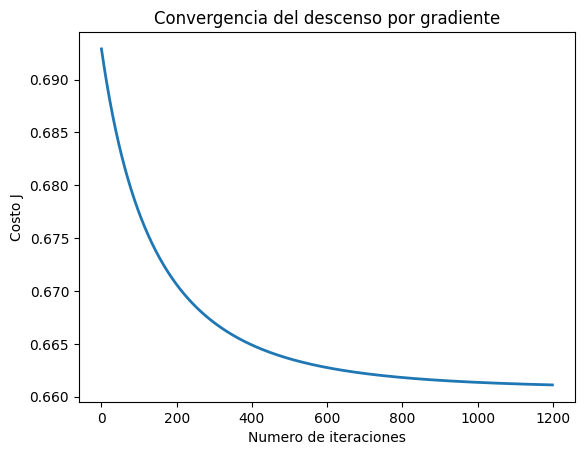

Theta calculado por descenso por gradiente (primeros 5): [-0.0038249   0.03061376 -0.00057083  0.03666379 -0.00094813]

Probabilidad de malware en máquina de ejemplo: 0.4850
Predicción: LIMPIA
Real:       MALWARE


In [17]:
alpha     = 0.01
num_iters = 1200
n         = X_train_norm.shape[1]  # 69 features

# Inicializar theta en ceros directamente — igual que el ingeniero
theta_gd = np.zeros(n + 1)
theta_gd, J_history = descensoGradiente(theta_gd, X_train_final, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por gradiente')
pyplot.show()

print('Theta calculado por descenso por gradiente (primeros 5): {:s}'.format(str(theta_gd[:5])))

# Predicción de ejemplo con máquina real
maquina_ejemplo = X_test_final[0]
prob = sigmoid(np.dot(maquina_ejemplo, theta_gd))
print()
print('Probabilidad de malware en máquina de ejemplo: {:.4f}'.format(prob))
print('Predicción: {}'.format('MALWARE' if prob >= 0.5 else 'LIMPIA'))
print('Real:       {}'.format('MALWARE' if y_test[0] == 1 else 'LIMPIA'))

In [18]:
# Predicción de ejemplo con la primera máquina del test
maquina_ejemplo = X_test_final[0]
prob = sigmoid(np.dot(maquina_ejemplo, theta_gd))

print('Probabilidad de malware en máquina de ejemplo: {:.4f}'.format(prob))
print('Predicción: {}'.format('MALWARE' if prob >= 0.5 else 'LIMPIA'))
print('Real:       {}'.format('MALWARE' if y_test[0] == 1 else 'LIMPIA'))

Probabilidad de malware en máquina de ejemplo: 0.4850
Predicción: LIMPIA
Real:       MALWARE


In [19]:
def costFunction(theta, X, y):
    m = y.size

    h    = sigmoid(X.dot(theta.T))
    J    = (1 / m) * np.sum(-y.dot(np.log(h + 1e-15)) - (1 - y).dot(np.log(1 - h + 1e-15)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

### Parámetros de aprendizaje usando `scipy.optimize`

En lugar de depender solo del descenso por gradiente manual, se utiliza `scipy.optimize.minimize` con el método TNC (Newton truncado). Se le pasa la función `costFunction` que devuelve tanto el costo $J(\theta)$ como el gradiente, y el optimizador encuentra el $\theta$ óptimo automáticamente.

Se prueba primero con $\theta$ en ceros y con un $\theta$ de prueba para verificar que `costFunction` funcione correctamente.

In [20]:
n = X_train_norm.shape[1]
initial_theta = np.zeros(n + 1)

cost, grad = costFunction(initial_theta, X_train_final, y_train)

print('Costo en theta inicial (zeros): {:.4f}'.format(cost))
print('Costo esperado (aproximado):    0.6931\n')
print('Norma del gradiente:            {:.4f}'.format(np.linalg.norm(grad)))
print('Primeros 5 valores del gradiente:', grad[:5])

Costo en theta inicial (zeros): 0.6931
Costo esperado (aproximado):    0.6931

Norma del gradiente:            0.1582
Primeros 5 valores del gradiente: [ 0.00025875  0.0016755   0.00022751 -0.02021656  0.01694876]


In [21]:
# Theta de prueba: -24 para intercepción, 0.2 para las 69 features
test_theta = np.append([-24], np.full(n, 0.2))

cost, grad = costFunction(test_theta, X_train_final, y_train)

print('Costo en theta prueba: {:.4f}'.format(cost))
print('Primeros 5 valores del gradiente:', grad[:5])

Costo en theta prueba: 12.0165
Primeros 5 valores del gradiente: [-0.49965536  0.00179655  0.0029659  -0.02029282  0.01694142]


In [22]:
options = {'maxfun': 5000}  # TNC usa maxfun — 5000 para convergencia adecuada con 69 features

res = optimize.minimize(
    costFunction,
    initial_theta,
    (X_train_final, y_train),
    jac=True,
    method='TNC',
    options=options
)

cost  = res.fun
theta = res.x

print('Costo con theta encontrado por optimize.minimize: {:.4f}'.format(cost))
print('Evaluaciones de función realizadas: {}'.format(res.nfev))
print('Iteraciones realizadas: {}'.format(res.nit))
print('Mensaje: {}'.format(res.message))
print('\nPrimeros 5 valores de theta:')
print('\t{}'.format(theta[:5]))

Costo con theta encontrado por optimize.minimize: 0.6598
Evaluaciones de función realizadas: 313
Iteraciones realizadas: 21
Mensaje: Converged (|f_n-f_(n-1)| ~= 0)

Primeros 5 valores de theta:
	[ 1.16796388  0.08295317 -0.00206699  0.08113058  0.0491523 ]


In [23]:
def plotTopFeatures(theta, feature_names, top_n=15):

    # Excluir θ₀ (intercepción)
    coefs = theta[1:]

    # Obtener índices de las top_n features por magnitud
    top_idx      = np.argsort(np.abs(coefs))[::-1][:top_n]
    top_nombres  = [feature_names[i] for i in top_idx]
    top_coefs    = coefs[top_idx]

    # Color rojo si positivo (aumenta riesgo), azul si negativo (reduce riesgo)
    colores = ['tomato' if c > 0 else 'steelblue' for c in top_coefs]

    pyplot.figure(figsize=(9, 6))
    pyplot.barh(top_nombres[::-1], top_coefs[::-1], color=colores[::-1])
    pyplot.axvline(0, color='black', linewidth=0.8)
    pyplot.xlabel('Coeficiente θ')
    pyplot.title('Top {} features más influyentes en detección de malware'.format(top_n))
    pyplot.tight_layout()
    pyplot.show()

### Visualización de features más influyentes

Se grafican las top 15 features con mayor magnitud de coeficiente $\theta$. Un coeficiente positivo (rojo) indica que esa feature **aumenta** la probabilidad de malware; uno negativo (azul) indica que la **reduce**.


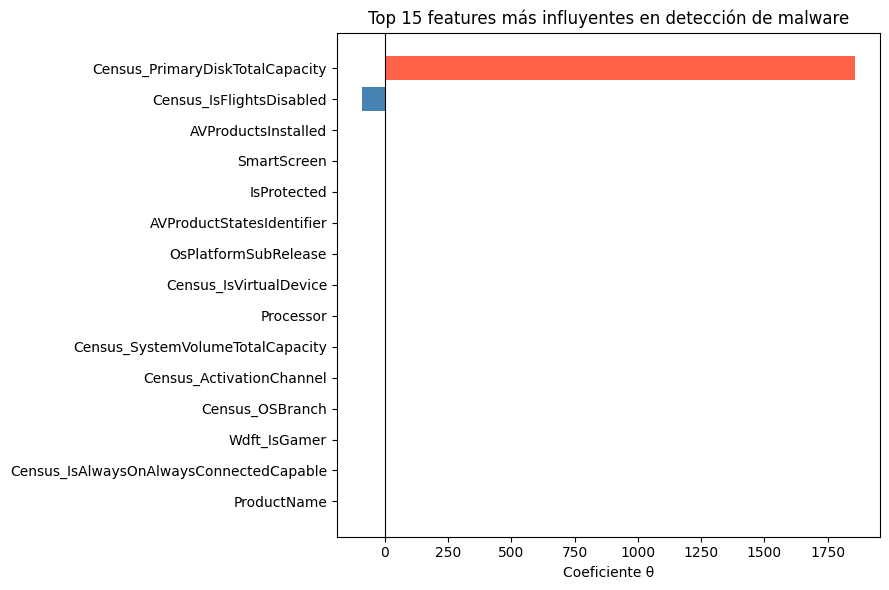

In [24]:
# Nombres de features (sin intercepción)
feature_names = df.columns.tolist()

plotTopFeatures(theta, feature_names, top_n=15)

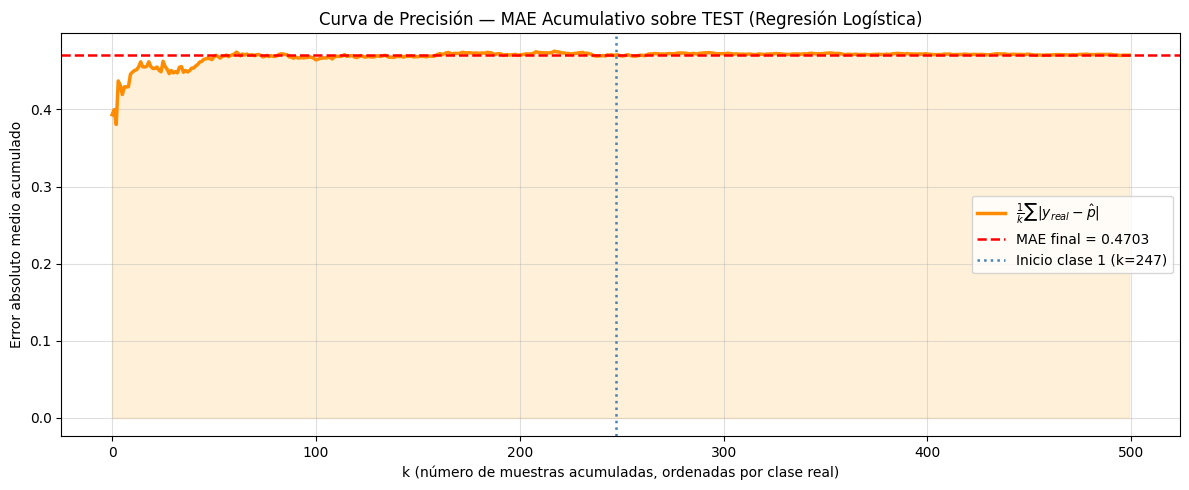

MAE final (todas las muestras): 0.4703
Interpretación: en promedio el modelo se aleja 0.4703 de la clase real


In [30]:
# Curva de precision

N = 500

# 
proba_test = sigmoid(X_test_final.dot(theta))

y_real = y_test[:N]
y_prob = proba_test[:N]


orden      = np.argsort(y_real)
y_real_ord = y_real[orden]
y_prob_ord = y_prob[orden]


errores_abs = np.abs(y_real_ord - y_prob_ord)           
error_acum  = np.cumsum(errores_abs) / np.arange(1, N + 1) 

# Línea divisoria entre clase 0 y clase 1
corte_clases = np.sum(y_real_ord == 0) 

pyplot.figure(figsize=(12, 5))
pyplot.plot(np.arange(N), error_acum, color='darkorange', lw=2.5,
            label=r'$\frac{1}{k}\sum|y_{real}-\hat{p}|$')
pyplot.axhline(y=error_acum[-1], color='red', linestyle='--', lw=1.8,
               label=f'MAE final = {error_acum[-1]:.4f}')
pyplot.axvline(x=corte_clases, color='steelblue', linestyle=':', lw=1.8,
               label=f'Inicio clase 1 (k={corte_clases})')
pyplot.fill_between(np.arange(N), error_acum, alpha=0.15, color='orange')
pyplot.xlabel('k (número de muestras acumuladas, ordenadas por clase real)')
pyplot.ylabel('Error absoluto medio acumulado')
pyplot.title('Curva de Precisión — MAE Acumulativo sobre TEST (Regresión Logística)')
pyplot.legend()
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print(f'MAE final (todas las muestras): {error_acum[-1]:.4f}')
print(f'Interpretación: en promedio el modelo se aleja {error_acum[-1]:.4f} de la clase real')

## Evaluación de la regresión logística

Después de encontrar los parámetros óptimos, se evalúa el modelo de varias formas:
- Predicción puntual sobre una máquina de ejemplo
- Precisión (accuracy) sobre train y test


In [25]:
def predict(theta, X):

    m = X.shape[0]
    p = np.zeros(m)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [26]:
# Predicción de ejemplo con una máquina real del test
maquina_ejemplo = X_test_final[0]
prob = sigmoid(np.dot(maquina_ejemplo, theta))
print('Probabilidad de malware en máquina de ejemplo: {:.4f}'.format(prob))
print('Predicción: {}'.format('MALWARE' if prob >= 0.5 else 'LIMPIA'))
print('Real:       {}'.format('MALWARE' if y_test[0] == 1 else 'LIMPIA'))
print()

# Precisión en train y test
p_train = predict(theta, X_train_final)
p_test  = predict(theta, X_test_final)

print('Precisión en entrenamiento: {:.2f}%'.format(np.mean(p_train == y_train) * 100))
print('Precisión en test:          {:.2f}%'.format(np.mean(p_test  == y_test)  * 100))

Probabilidad de malware en máquina de ejemplo: 0.4664
Predicción: LIMPIA
Real:       MALWARE

Precisión en entrenamiento: 60.53%
Precisión en test:          60.65%


In [27]:
np.save('theta_optimo.npy', theta)
print('Modelo guardado correctamente')

Modelo guardado correctamente


In [28]:
import gradio as gr

feature_names = df.columns.tolist()
coefs         = theta[1:]
top_idx       = np.argsort(np.abs(coefs))[::-1][:10]
top_features  = [feature_names[i] for i in top_idx]
top_coefs     = coefs[top_idx]

# Descripciones en español para cada feature
descripciones = {
    'Census_PrimaryDiskTotalCapacity' : 'Capacidad total del disco principal (MB)',
    'Census_IsFlightsDisabled'        : 'Actualizaciones experimentales desactivadas (0=No, 1=Sí)',
    'AVProductsInstalled'             : 'Número de antivirus instalados',
    'SmartScreen'                     : 'Configuración de SmartScreen (0=Desactivado ... 14=Activo)',
    'IsProtected'                     : 'Máquina protegida con antivirus activo (0=No, 1=Sí)',
    'AVProductStatesIdentifier'       : 'Identificador del estado del antivirus',
    'OsPlatformSubRelease'            : 'Versión del sistema operativo (0=Vista ... 8=Win10)',
    'Census_IsVirtualDevice'          : 'Es una máquina virtual (0=No, 1=Sí)',
    'Processor'                       : 'Arquitectura del procesador (0=x86, 1=x64, 2=ARM)',
    'Census_SystemVolumeTotalCapacity': 'Capacidad de la partición del sistema (MB)',
}

def predecir_malware(*inputs):
    x = np.array([df[col].median() for col in feature_names])
    
    for i, idx in enumerate(top_idx):
        x[idx] = float(inputs[i])
    
    x_norm  = (x - mu) / sigma
    x_final = np.concatenate([[1], x_norm])
    
    prob      = float(sigmoid(np.dot(x_final, theta)))
    resultado = 'Malware detectado' if prob >= 0.5 else 'Máquina limpia'
    nivel     = 'Alto' if prob >= 0.7 else ('Medio' if prob >= 0.4 else 'Bajo')
    
    tabla_coefs = '\n'.join([
        '{:<45} {:>+.4f}'.format(f, c)
        for f, c in zip(top_features, top_coefs)
    ])
    
    return resultado, '{:.1f}%'.format(prob * 100), nivel, tabla_coefs

# Inputs con descripción en español
inputs = []
for feat in top_features:
    val_min = float(df[feat].min())
    val_max = float(df[feat].max())
    val_med = float(df[feat].median())
    inputs.append(
        gr.Slider(
            minimum=val_min,
            maximum=val_max,
            value=val_med,
            label=descripciones.get(feat, feat),
            info='Valor típico: {:.2f}  |  Rango: {:.2f} — {:.2f}'.format(val_med, val_min, val_max)
        )
    )

outputs = [
    gr.Textbox(label='Resultado'),
    gr.Textbox(label='Probabilidad de malware'),
    gr.Textbox(label='Nivel de riesgo'),
    gr.Textbox(label='Coeficientes theta por feature')
]

demo = gr.Interface(
    fn=predecir_malware,
    inputs=inputs,
    outputs=outputs,
    title='Microsoft Malware Prediction',
    description=(
        'Predictor basado en regresión logística implementada desde cero con numpy y scipy.\n'
        'Ajusta las características de la máquina para obtener la probabilidad de infección.\n\n'
        'Coeficiente positivo: aumenta el riesgo de malware\n'
        'Coeficiente negativo: reduce el riesgo de malware'
    ),
    theme=gr.themes.Soft(),
    flagging_mode='never'
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b25014ebe254416a99.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [29]:
# Predicciones en train y test
p_train = predict(theta, X_train_final)
p_test  = predict(theta, X_test_final)

# Precisión general
print('='*50)
print('PRECISIÓN DEL MODELO')
print('='*50)
print('Precisión en entrenamiento: {:.2f}%'.format(np.mean(p_train == y_train) * 100))
print('Precisión en test:          {:.2f}%'.format(np.mean(p_test  == y_test)  * 100))

# Precisión por clase
print()
print('='*50)
print('PRECISIÓN POR CLASE (TEST)')
print('='*50)

# Clase 0 — máquinas limpias
idx_limpias = y_test == 0
print('Máquinas limpias  (y=0): {}/{} correctas  ({:.2f}%)'.format(
    int(np.sum(p_test[idx_limpias] == 0)),
    int(np.sum(idx_limpias)),
    np.mean(p_test[idx_limpias] == 0) * 100
))

# Clase 1 — máquinas con malware
idx_malware = y_test == 1
print('Máquinas malware  (y=1): {}/{} correctas  ({:.2f}%)'.format(
    int(np.sum(p_test[idx_malware] == 1)),
    int(np.sum(idx_malware)),
    np.mean(p_test[idx_malware] == 1) * 100
))

# Resumen total
print()
print('='*50)
print('RESUMEN')
print('='*50)
print('Total ejemplos test:      {:,}'.format(len(y_test)))
print('Correctamente predichos:  {:,}'.format(int(np.sum(p_test == y_test))))
print('Incorrectamente predichos:{:,}'.format(int(np.sum(p_test != y_test))))

PRECISIÓN DEL MODELO
Precisión en entrenamiento: 60.53%
Precisión en test:          60.65%

PRECISIÓN POR CLASE (TEST)
Máquinas limpias  (y=0): 114089/199659 correctas  (57.14%)
Máquinas malware  (y=1): 128508/200341 correctas  (64.14%)

RESUMEN
Total ejemplos test:      400,000
Correctamente predichos:  242,597
Incorrectamente predichos:157,403
